# 99 — Betsy Gun nodal vs Geode single-shot alignment

Purpose:

1. Find the Betsy Gun Geode shot metadata.
2. Find the corresponding **single** nodal event.
3. Plot the Betsy Gun shot gather on the nodals.
4. Plot the Geode gather for comparison.
5. Correlate Geode and nodal data at common receiver positions.
6. Estimate the best overall Geode→nodal time shift.
7. Produce a combined normalized shot gather on one plot.

This notebook is deliberately focused on the Betsy Gun single shot, not the repeated hammer/PEG stacks.

Inputs:
- `geode_events`
- `nodal_source_estimates`
- `shot_gather_files`
- `trace_index`

Outputs/replaces only:
- `betsy_nodal_geode_alignment`
- `betsy_alignment_trace_correlations`
- `betsy_alignment_files`
- `betsy_alignment_errors`

In [1]:
from pathlib import Path
import sys
import sqlite3
import traceback
import importlib.util
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from obspy import read, Stream, UTCDateTime

PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"
CATALOG_DB.parent.mkdir(parents=True, exist_ok=True)

OUT_ROOT = PROJECT_ROOT / "betsy_gun_alignment_v1"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Import segy_tools geometry helpers.
sys.path.append('../../lib')

try:
    from segy_tools.gather import stream_to_gather_arrays, gather_arrays_to_stream
    print("Imported segy_tools.gather from package path.")
except Exception as e:
    print("Could not import segy_tools.gather:", repr(e))
    local_gather = Path("/mnt/data/gather.py")
    if local_gather.exists():
        spec = importlib.util.spec_from_file_location("gather_local", local_gather)
        gather_local = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(gather_local)
        stream_to_gather_arrays = gather_local.stream_to_gather_arrays
        gather_arrays_to_stream = gather_local.gather_arrays_to_stream
        print("Imported uploaded gather.py fallback.")
    else:
        raise

NODAL_COMPONENT = "Z"
NODAL_COMPONENTS_TO_EXPORT = ["Z", "N", "E"]
# Geode files may not have conventional *Z channel names, so use None to keep all traces.
GEODE_COMPONENT = None
COMPONENT = NODAL_COMPONENT

# Search/matching controls.
BETSY_SEARCH_TERMS = ["betsy", "betsey", "buffalo"]
MANUAL_GEODE_EVENT_ID = "GEODE_T1_2M_REFRACTION_F3088"
MANUAL_NODAL_EVENT_ID = "T1_N2_Refraction2m_T1_N2_E00449"

NODAL_SEARCH_BEFORE_S = 3.0
NODAL_SEARCH_AFTER_S = 3.0
SOURCE_TOLERANCE_M = 3.0

# Set True for diagnostic runs: first find candidates by time, then inspect source-position residuals.
DO_NOT_REQUIRE_SOURCE_MATCH_FOR_BETSY = False

# Correlation controls.
BANDPASS_FREQMIN_HZ = 5.0
BANDPASS_FREQMAX_HZ = 150.0
XCORR_TMIN_S = 0.0
XCORR_TMAX_S = 0.8
MAX_SHIFT_S = 0.25
COMMON_RECEIVER_TOL_M = 1.1
MIN_TRACE_CORR = 0.30

# Plot controls.
PLOT_TMIN_S = 0.0
PLOT_TMAX_S = 0.8
CLIP_PERCENTILE = 99
TRACE_SCALE = 0.7

WRITE_TABLES = True

print("CATALOG_DB:", CATALOG_DB)
print("OUT_ROOT:", OUT_ROOT)

Imported segy_tools.gather from package path.
CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
OUT_ROOT: /Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1


## 1. Load required catalog tables

In [2]:
REQUIRED = ["geode_events", "nodal_source_estimates", "shot_gather_files", "trace_index"]
OWNED = [
    "betsy_nodal_geode_alignment",
    "betsy_alignment_trace_correlations",
    "betsy_alignment_files",
    "betsy_alignment_errors",
]

if not CATALOG_DB.exists():
    raise FileNotFoundError(CATALOG_DB)

with sqlite3.connect(CATALOG_DB) as conn:
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"].tolist()

missing = [t for t in REQUIRED if t not in tables]
if missing:
    raise RuntimeError(f"Missing required inputs: {missing}. Run 90, 92, and 93 first.")

conn = sqlite3.connect(CATALOG_DB)
geode_events = pd.read_sql("SELECT * FROM geode_events", conn)
nodal_source_estimates = pd.read_sql("SELECT * FROM nodal_source_estimates", conn)
shot_gather_files = pd.read_sql("SELECT * FROM shot_gather_files WHERE instrument_system='nodal'", conn)
trace_index = pd.read_sql("SELECT * FROM trace_index WHERE instrument_system='nodal'", conn)

geode_events["geode_final_trigger_dt"] = pd.to_datetime(geode_events["geode_final_trigger_time_utc"], errors="coerce", utc=True)
geode_events["source_x_m"] = pd.to_numeric(geode_events["source_x_m"], errors="coerce")

nodal_source_estimates["event_time_dt"] = pd.to_datetime(nodal_source_estimates["event_time_utc"], errors="coerce", utc=True)
nodal_source_estimates["estimated_source_x_m"] = pd.to_numeric(nodal_source_estimates["estimated_source_x_m"], errors="coerce")

print("geode_events:", len(geode_events))
print("nodal_source_estimates:", len(nodal_source_estimates))
display(geode_events.groupby(["survey", "source_type"], dropna=False).size().reset_index(name="n").head(50))

geode_events: 242
nodal_source_estimates: 3436


,survey,source_type,n
0,T1_1m_refraction,hammer,46
1,T1_2m_refraction,hammer,44
2,T1_streamer_masw,PEG,83
3,T3_1m_refraction,hammer,39
4,T4_1m_refraction,hammer,30


## 2. Find Betsy Gun Geode shot

In [3]:

if MANUAL_GEODE_EVENT_ID:
    betsy_geode = geode_events[
        geode_events["geode_event_id"].astype(str).eq(str(MANUAL_GEODE_EVENT_ID))
    ].copy()
else:
    mask = geode_events.apply(lambda r: any(term in row_text(r) for term in BETSY_SEARCH_TERMS), axis=1)
    betsy_geode = geode_events[mask].copy()

betsy_geode = betsy_geode.dropna(subset=["geode_final_trigger_dt", "source_x_m"]).copy()
betsy_geode["geode_file_exists"] = betsy_geode["geode_file_path"].apply(lambda p: Path(str(p)).exists() if pd.notna(p) else False)

print("Betsy candidate Geode rows:", len(betsy_geode))
display(
    betsy_geode[
        [
            "geode_event_id", "survey", "line", "file_no", "source_x_m", "source_type",
            "geode_final_trigger_time_utc", "geode_file_path", "geode_file_exists", "comment"
        ]
    ]
)

if len(betsy_geode) == 0:
    raise RuntimeError("No matching Geode row found. Check MANUAL_GEODE_EVENT_ID or geode_events file_no/source metadata.")

geode_row = betsy_geode.iloc[0]
print("Selected:", geode_row["geode_event_id"], geode_row["survey"], geode_row["source_x_m"])


Betsy candidate Geode rows: 1


,geode_event_id,survey,line,file_no,source_x_m,source_type,geode_final_trigger_time_utc,geode_file_path,geode_file_exists,comment
87,GEODE_T1_2M_REFRACTION_F3088,T1_2m_refraction,T1,3088.0,47.0,hammer,2026-05-18T23:12:42+00:00,/Volumes/tachyon/LBSSP_DATA/GEODE_DATA/LBSSP_0...,True,Betsy / extra source test at 47 m; blow count ...


Selected: GEODE_T1_2M_REFRACTION_F3088 T1_2m_refraction 47.0


## 3. Find matching single nodal event

In [4]:

def nodal_mseed_path(event_id):
    rows = shot_gather_files[
        (shot_gather_files["event_id"].astype(str).eq(str(event_id))) &
        (shot_gather_files["file_type"].astype(str).str.lower().eq("mseed"))
    ]
    if rows.empty:
        return None
    p = Path(rows.iloc[0]["file_path"])
    return p if p.exists() else None


def candidate_nodal_events_for_geode(geode_row, before_s, after_s, source_tolerance_m=None, require_source_match=False):
    t0 = geode_row["geode_final_trigger_dt"]
    sx = float(geode_row["source_x_m"])

    cand0 = nodal_source_estimates.dropna(subset=["event_time_dt"]).copy()

    # Prefer same line if available, but do NOT require it. Betsy metadata may be unusual.
    if "line" in cand0.columns and pd.notna(geode_row.get("line")):
        same_line = cand0[cand0["line"].astype(str).eq(str(geode_row["line"]))].copy()
        if len(same_line):
            cand0 = same_line

    cand0 = cand0[
        (cand0["event_time_dt"] >= t0 - pd.to_timedelta(before_s, unit="s")) &
        (cand0["event_time_dt"] <= t0 + pd.to_timedelta(after_s, unit="s"))
    ].copy()

    cand0["source_x_truth_m"] = sx
    cand0["source_x_residual_m"] = cand0["estimated_source_x_m"] - sx
    cand0["abs_source_x_residual_m"] = cand0["source_x_residual_m"].abs()
    cand0["time_from_geode_s"] = (cand0["event_time_dt"] - t0).dt.total_seconds()
    cand0["abs_time_from_geode_s"] = cand0["time_from_geode_s"].abs()
    cand0["mseed_path"] = cand0["event_id"].apply(nodal_mseed_path)
    cand0["mseed_exists"] = cand0["mseed_path"].apply(lambda p: p is not None and Path(p).exists())

    if require_source_match and source_tolerance_m is not None:
        cand0 = cand0[cand0["abs_source_x_residual_m"] <= source_tolerance_m].copy()

    return cand0.sort_values(["abs_time_from_geode_s", "abs_source_x_residual_m"]).copy()


if MANUAL_NODAL_EVENT_ID:
    cand = nodal_source_estimates[nodal_source_estimates["event_id"].astype(str).eq(MANUAL_NODAL_EVENT_ID)].copy()
    t0 = geode_row["geode_final_trigger_dt"]
    sx = float(geode_row["source_x_m"])
    cand["source_x_truth_m"] = sx
    cand["source_x_residual_m"] = cand["estimated_source_x_m"] - sx
    cand["abs_source_x_residual_m"] = cand["source_x_residual_m"].abs()
    cand["time_from_geode_s"] = (cand["event_time_dt"] - t0).dt.total_seconds()
    cand["abs_time_from_geode_s"] = cand["time_from_geode_s"].abs()
    cand["mseed_path"] = cand["event_id"].apply(nodal_mseed_path)
    cand["mseed_exists"] = cand["mseed_path"].apply(lambda p: p is not None and Path(p).exists())
else:
    # First pass: broad diagnostic search by time only.
    cand_time_only = candidate_nodal_events_for_geode(
        geode_row,
        before_s=NODAL_SEARCH_BEFORE_S,
        after_s=NODAL_SEARCH_AFTER_S,
        source_tolerance_m=SOURCE_TOLERANCE_M,
        require_source_match=False,
    )

    print("Time-only nodal candidates:", len(cand_time_only))
    if len(cand_time_only):
        display(
            cand_time_only[
                [
                    "event_id", "line", "timewindow_label", "event_time_utc",
                    "estimated_source_x_m", "source_x_residual_m",
                    "abs_source_x_residual_m",
                    "time_from_geode_s", "mseed_path", "mseed_exists"
                ]
            ].head(40)
        )
        print("mseed_exists counts:")
        display(cand_time_only["mseed_exists"].value_counts(dropna=False))

    if DO_NOT_REQUIRE_SOURCE_MATCH_FOR_BETSY:
        cand = cand_time_only.copy()
    else:
        cand = cand_time_only[cand_time_only["abs_source_x_residual_m"] <= SOURCE_TOLERANCE_M].copy()

# Pick nearest-time candidate with an existing MiniSEED.
cand_with_mseed = cand[cand["mseed_exists"]].copy()

if len(cand_with_mseed) == 0:
    # Better diagnostic instead of stopping without context.
    print("No nodal candidates with MiniSEED after current filters.")
    print("Selected Geode row:")
    display(
        pd.DataFrame([geode_row])[
            [
                "geode_event_id", "survey", "line", "file_no", "source_x_m",
                "source_type", "geode_final_trigger_time_utc", "geode_file_path"
            ]
        ]
    )

    # Show nearest nodal events in a much wider time window, no source filter.
    wide = candidate_nodal_events_for_geode(
        geode_row,
        before_s=900.0,
        after_s=900.0,
        source_tolerance_m=None,
        require_source_match=False,
    )
    print("Nearest nodal events within +/-900 s, no source filter:")
    display(
        wide[
            [
                "event_id", "line", "timewindow_label", "event_time_utc",
                "estimated_source_x_m", "source_x_residual_m",
                "time_from_geode_s", "mseed_path", "mseed_exists"
            ]
        ].head(60)
    )

    raise RuntimeError(
        "No matching nodal event with MiniSEED found. Use the diagnostic table above. "
        "Most likely fixes: set MANUAL_NODAL_EVENT_ID to the correct row, widen the search window, "
        "or confirm that 90_* generated mseed shot gathers for the Betsy time window."
    )

nodal_row = cand_with_mseed.iloc[0]
print("Selected nodal event:", nodal_row["event_id"], nodal_row["event_time_utc"], nodal_row.get("estimated_source_x_m"))
print("time_from_geode_s:", nodal_row.get("time_from_geode_s"))
print("source_x_residual_m:", nodal_row.get("source_x_residual_m"))
print("mseed_path:", nodal_row["mseed_path"])


Selected nodal event: T1_N2_Refraction2m_T1_N2_E00449 2026-05-18T23:12:41.858000+00:00 71.69555372202365
time_from_geode_s: -0.142
source_x_residual_m: 24.695553722023647
mseed_path: /Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N2_Refraction2m/gathers_mseed/T1_N2_Refraction2m_T1_N2_E00449_DPall.mseed


## 4. Geometry and waveform helpers

In [5]:
def select_component(st, component=COMPONENT):
    stc = st.select(channel=f"*{component}").copy()
    return stc if len(stc) else st.copy()


def infer_geode_receiver_xs(geode_row, n_traces):
    first = pd.to_numeric(geode_row.get("receiver_first_m"), errors="coerce")
    last = pd.to_numeric(geode_row.get("receiver_last_m"), errors="coerce")
    spacing = pd.to_numeric(geode_row.get("receiver_spacing_m"), errors="coerce")

    if np.isfinite(first) and np.isfinite(spacing) and spacing != 0:
        return (first + np.arange(n_traces) * spacing).astype(float), "receiver_first_m + receiver_spacing_m"

    if np.isfinite(first) and np.isfinite(last) and n_traces > 1:
        return np.linspace(first, last, n_traces).astype(float), "linspace(receiver_first_m, receiver_last_m)"

    return np.arange(n_traces, dtype=float), "trace_index_fallback"


def attach_geode_geometry(st, geode_row):
    st = st.copy()
    xs, method = infer_geode_receiver_xs(geode_row, len(st))
    source_x = pd.to_numeric(geode_row.get("source_x_m"), errors="coerce")
    for tr, x in zip(st, xs):
        tr.stats.receiver_x_m = float(x)
        if np.isfinite(source_x):
            tr.stats.source_x_m = float(source_x)
    return st, method


def attach_nodal_geometry(st, event_id, source_x_m=None, component=COMPONENT):
    geom = trace_index[trace_index["event_id"].astype(str).eq(str(event_id))].copy()
    if component:
        geom = geom[geom["channel"].astype(str).str.endswith(component)].copy()

    geom["receiver_x_m"] = pd.to_numeric(geom["receiver_x_m"], errors="coerce")
    geom = geom.dropna(subset=["receiver_x_m"])

    lookup = {}
    for _, r in geom.iterrows():
        station = str(r.get("station", ""))
        channel = str(r.get("channel", ""))
        network = str(r.get("network", ""))
        location = "" if pd.isna(r.get("location", "")) else str(r.get("location", ""))
        lookup[(station, channel)] = float(r["receiver_x_m"])
        lookup[f"{network}.{station}.{location}.{channel}"] = float(r["receiver_x_m"])
        if "seed_id" in geom.columns and pd.notna(r.get("seed_id")):
            lookup[str(r["seed_id"])] = float(r["receiver_x_m"])

    st = st.copy()
    n_attached = 0
    for tr in st:
        x = lookup.get((str(tr.stats.station), str(tr.stats.channel)), lookup.get(tr.id))
        if x is None:
            try:
                x = float(str(tr.stats.station)) / 100.0
            except Exception:
                x = None

        if x is not None and np.isfinite(float(x)):
            tr.stats.receiver_x_m = float(x)
            n_attached += 1

        if source_x_m is not None and np.isfinite(source_x_m):
            tr.stats.source_x_m = float(source_x_m)

    return st, f"trace_index event_id={event_id}; attached {n_attached}/{len(st)} traces"


def shift_stream_to_relative_time(st):
    if len(st) == 0:
        return st
    origin = min(tr.stats.starttime for tr in st)
    out = st.copy()
    for tr in out:
        rel = tr.stats.starttime - origin
        tr.stats.starttime = UTCDateTime(0) + rel
    return out


def preprocess_for_alignment(st):
    st = st.copy()
    for tr in st:
        tr.data = tr.data.astype(np.float64)
        tr.detrend("linear")
        tr.taper(max_percentage=0.02)
        nyq = 0.5 / tr.stats.delta
        if BANDPASS_FREQMAX_HZ < 0.95 * nyq:
            tr.filter("bandpass", freqmin=BANDPASS_FREQMIN_HZ, freqmax=BANDPASS_FREQMAX_HZ, corners=4, zerophase=True)
        else:
            tr.filter("highpass", freq=BANDPASS_FREQMIN_HZ, corners=4, zerophase=True)
    return st


def safe_name(s):
    s = str(s)
    for ch in [" ", "/", "\\", ":", ";", ",", "(", ")", "[", "]"]:
        s = s.replace(ch, "_")
    return s

## 5. Load Betsy nodal and Geode gathers

In [6]:
source_x = float(geode_row["source_x_m"])

st_nodal = read(str(nodal_row["mseed_path"]))
st_nodal = select_component(st_nodal, NODAL_COMPONENT)
st_nodal, nodal_geom_method = attach_nodal_geometry(st_nodal, nodal_row["event_id"], source_x_m=source_x, component=NODAL_COMPONENT)
st_nodal = shift_stream_to_relative_time(st_nodal)
st_nodal = preprocess_for_alignment(st_nodal)

st_geode = read(str(geode_row["geode_file_path"]))
# Do not force *Z selection for Geode; many Geode traces do not use normal component suffixes.
st_geode = select_component(st_geode, GEODE_COMPONENT)
st_geode, geode_geom_method = attach_geode_geometry(st_geode, geode_row)
st_geode = shift_stream_to_relative_time(st_geode)
st_geode = preprocess_for_alignment(st_geode)

print("Nodal:", len(st_nodal), nodal_geom_method)
print("Geode:", len(st_geode), geode_geom_method)
print("Nodal file:", nodal_row["mseed_path"])
print("Geode file:", geode_row["geode_file_path"])

Nodal: 34 trace_index event_id=T1_N2_Refraction2m_T1_N2_E00449; attached 34/34 traces
Geode: 72 receiver_first_m + receiver_spacing_m
Nodal file: /Volumes/tachyon/LBSSP_DATA/nodal_fullnode_shotgathers_v4/T1_N2_Refraction2m/gathers_mseed/T1_N2_Refraction2m_T1_N2_E00449_DPall.mseed
Geode file: /Volumes/tachyon/LBSSP_DATA/GEODE_DATA/LBSSP_051826/3088.dat


/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/obspy/io/seg2/seg2.py:365: UserWarning: Many companies use custom defined SEG2 header variables. This might cause basic header information reflected in the single traces' stats to be wrong (e.g. recording delays, first sample number, station code names, ..). Please check the complete list of additional unmapped header fields that gets stored in Trace.stats.seg2 and/or the manual of the source of the SEG2 files for fields that might influence e.g. trace start times.
  warnings.warn(WARNING_HEADER)


## 6. Convert to gather arrays with `segy_tools`

In [7]:
print("Nodal channels:", sorted(set(tr.stats.channel for tr in st_nodal)))
print("Geode channels:", sorted(set(tr.stats.channel for tr in st_geode)))

t_n, d_n, x_n, sx_n, geom_n = stream_to_gather_arrays(
    st_nodal,
    sort_by="receiver_x",
    component=NODAL_COMPONENT,
    fallback_source_x_m=source_x,
)

t_g, d_g, x_g, sx_g, geom_g = stream_to_gather_arrays(
    st_geode,
    sort_by="receiver_x",
    component=GEODE_COMPONENT,
    fallback_source_x_m=source_x,
)

print("Nodal gather:", d_n.shape, "x range", np.nanmin(x_n), np.nanmax(x_n))
print("Geode gather:", d_g.shape, "x range", np.nanmin(x_g), np.nanmax(x_g))

Nodal channels: ['DPZ']
Geode channels: ['']
Nodal gather: (34, 501) x range 68.09 184.05
Geode gather: (72, 4800) x range 52.0 194.0


## 7. Find common receivers and estimate Geode→nodal time shift

In [8]:
def interp_at_time(t_src, y_src, t_grid):
    return np.interp(t_grid, t_src, y_src, left=np.nan, right=np.nan)

def normalize(y):
    y = np.asarray(y, dtype=float)
    y = y - np.nanmedian(y)
    sd = np.nanstd(y)
    if not np.isfinite(sd) or sd <= 0:
        return None
    y[~np.isfinite(y)] = 0
    return y / sd

def xcorr_shift(ref, cand, dt, max_shift_s):
    ref = normalize(ref)
    cand = normalize(cand)
    if ref is None or cand is None:
        return np.nan, np.nan

    cc = correlate(cand, ref, mode="full")
    lags = correlation_lags(len(cand), len(ref), mode="full")
    maxlag = int(round(max_shift_s / dt))
    ok = np.abs(lags) <= maxlag
    if not ok.any():
        return np.nan, np.nan
    cc2 = cc[ok]
    l2 = lags[ok]
    k = int(np.nanargmax(cc2))
    lag = int(l2[k])

    # correlate(candidate, reference): positive lag means candidate is later.
    # shift_to_apply_to_candidate = -lag * dt
    shift_s = -lag * dt

    denom = np.sqrt(np.nansum(ref**2) * np.nansum(cand**2))
    corrcoef = float(cc2[k] / denom) if denom > 0 else np.nan
    return float(shift_s), corrcoef

# Common time grid for correlation.
dt = max(np.nanmedian(np.diff(t_n)), np.nanmedian(np.diff(t_g)))
t_grid = np.arange(XCORR_TMIN_S, XCORR_TMAX_S + 0.5 * dt, dt)

rows = []

for inod, xn in enumerate(x_n):
    j = int(np.nanargmin(np.abs(x_g - xn)))
    dx = float(x_g[j] - xn)
    if abs(dx) > COMMON_RECEIVER_TOL_M:
        continue

    yn = interp_at_time(t_n, d_n[inod], t_grid)
    yg = interp_at_time(t_g, d_g[j], t_grid)

    shift_s, corrcoef = xcorr_shift(yn, yg, dt, MAX_SHIFT_S)

    rows.append({
        "nodal_receiver_x_m": float(xn),
        "geode_receiver_x_m": float(x_g[j]),
        "receiver_dx_m": dx,
        "nodal_trace_index": int(inod),
        "geode_trace_index": int(j),
        "geode_shift_to_apply_s": shift_s,
        "corrcoef": corrcoef,
    })

trace_corrs = pd.DataFrame(rows)
trace_corrs["accepted"] = (
    np.isfinite(trace_corrs["geode_shift_to_apply_s"]) &
    np.isfinite(trace_corrs["corrcoef"]) &
    (trace_corrs["corrcoef"] >= MIN_TRACE_CORR)
)

display(trace_corrs.sort_values("corrcoef", ascending=False).head(20))
print("Common receivers:", len(trace_corrs))
print("Accepted correlations:", int(trace_corrs["accepted"].sum()) if len(trace_corrs) else 0)

if len(trace_corrs) and trace_corrs["accepted"].any():
    best_shift_s = float(trace_corrs.loc[trace_corrs["accepted"], "geode_shift_to_apply_s"].median())
    median_corr = float(trace_corrs.loc[trace_corrs["accepted"], "corrcoef"].median())
else:
    best_shift_s = 0.0
    median_corr = np.nan

print("Best overall Geode shift to apply (s):", best_shift_s)
print("Median accepted corrcoef:", median_corr)

,nodal_receiver_x_m,geode_receiver_x_m,receiver_dx_m,nodal_trace_index,geode_trace_index,geode_shift_to_apply_s,corrcoef,accepted
2,80.03,80.0,-0.03,2,14,0.066,0.992624,True
4,88.08,88.0,-0.08,4,18,0.066,0.991519,True
0,68.09,68.0,-0.09,0,8,0.066,0.989134,True
3,84.05,84.0,-0.05,3,16,0.066,0.985640,True
1,76.00,76.0,0.00,1,12,0.066,0.983093,True
6,96.05,96.0,-0.05,6,22,0.066,0.982444,True
14,117.97,118.0,0.03,14,33,0.064,0.979228,True
13,116.11,116.0,-0.11,13,32,0.066,0.976184,True
9,106.03,106.0,-0.03,9,27,0.066,0.975282,True
8,104.08,104.0,-0.08,8,26,0.066,0.973404,True


Common receivers: 34
Accepted correlations: 34
Best overall Geode shift to apply (s): 0.06600000000000006
Median accepted corrcoef: 0.9577255215483104


## 8. Combined normalized shot-gather plot

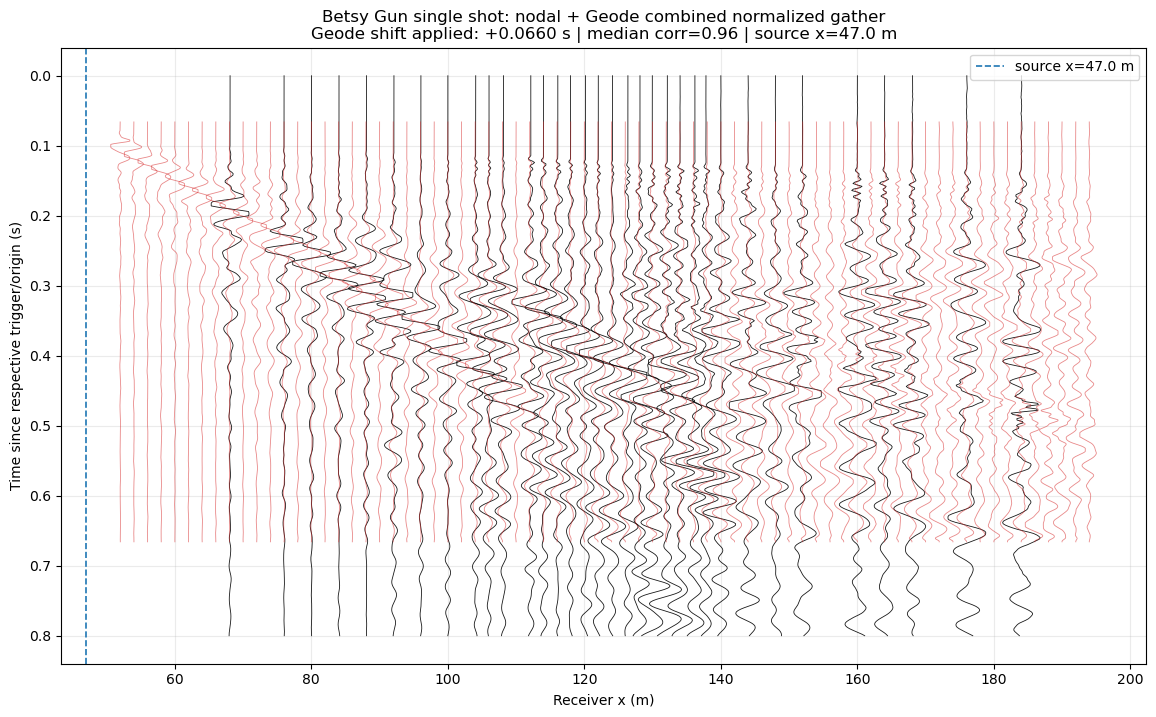

/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1/BETSY_GEODE_T1_2M_REFRACTION_F3088_T1_N2_Refraction2m_T1_N2_E00449_combined_shifted.png


In [9]:
def normalize_traces_for_plot(data):
    out = data.astype(float).copy()
    out = out - np.nanmedian(out, axis=1)[:, None]
    scale = np.nanpercentile(np.abs(out), CLIP_PERCENTILE, axis=1)
    scale[~np.isfinite(scale) | (scale <= 0)] = 1.0
    return out / scale[:, None]

def plot_single_dataset(ax, time, data, rx, label, linestyle="-", alpha=0.85, shift_s=0.0, color=None):
    mask = (time + shift_s >= PLOT_TMIN_S) & (time + shift_s <= PLOT_TMAX_S)
    tt = time[mask] + shift_s
    dd = normalize_traces_for_plot(data[:, mask])
    rx = np.asarray(rx, dtype=float)

    ux = np.sort(np.unique(rx[np.isfinite(rx)]))
    dx = np.nanmedian(np.diff(ux)) if len(ux) > 1 else 1.0
    if not np.isfinite(dx) or dx <= 0:
        dx = 1.0

    for i, x in enumerate(rx):
        yy = x + TRACE_SCALE * dx * np.clip(dd[i], -1, 1)
        ax.plot(yy, tt, linestyle=linestyle, alpha=alpha, linewidth=0.6, color=color)

fig, ax = plt.subplots(figsize=(14, 8))

plot_single_dataset(ax, t_n, d_n, x_n, label="Nodal", linestyle="-", alpha=0.9, shift_s=0.0, color="black")
plot_single_dataset(ax, t_g, d_g, x_g, label="Geode shifted", linestyle="-", alpha=0.55, shift_s=best_shift_s, color="tab:red")

ax.axvline(source_x, linestyle="--", linewidth=1.2, color="tab:blue", label=f"source x={source_x:.1f} m")
ax.invert_yaxis()
ax.set_xlabel("Receiver x (m)")
ax.set_ylabel("Time since respective trigger/origin (s)")
ax.set_title(
    f"Betsy Gun single shot: nodal + Geode combined normalized gather\n"
    f"Geode shift applied: {best_shift_s:+.4f} s | median corr={median_corr:.2f} | source x={source_x:.1f} m"
)
ax.grid(True, alpha=0.25)
ax.legend()

out_png = OUT_ROOT / f"BETSY_{safe_name(str(geode_row['geode_event_id']))}_{safe_name(str(nodal_row['event_id']))}_combined_shifted.png"
fig.savefig(out_png, dpi=180)
plt.show()

print(out_png)

## 8b. Export Betsy nodal, Geode, and combined gathers as SEG-Y

In [10]:

# SEG-Y exports for RefraPy.
#
# These are processed/aligned products from this notebook:
#   - nodal: nodal Betsy event, resampled to the common output time grid
#   - geode_shifted: Geode file 3088, shifted by best_shift_s and resampled to the same grid
#   - combined: nodal + shifted Geode traces in one SEG-Y gather
#
# A CSV trace manifest is written beside the SEG-Y files because SEG-Y headers
# cannot safely preserve all provenance fields needed for review.

SEGY_OUT = OUT_ROOT / "segy_for_refrapy"
SEGY_OUT.mkdir(parents=True, exist_ok=True)

EXPORT_TMIN_S = PLOT_TMIN_S
EXPORT_TMAX_S = PLOT_TMAX_S

# Use nodal sample interval for common export, because nodals are the reference dataset.
dt_n = float(np.nanmedian(np.diff(t_n)))
dt_g = float(np.nanmedian(np.diff(t_g)))
dt_out = dt_n

t_out = np.arange(EXPORT_TMIN_S, EXPORT_TMAX_S + 0.5 * dt_out, dt_out)

def resample_gather_to_grid(time, data, t_grid, time_shift_s=0.0):
    """
    Return data sampled on t_grid.

    If time_shift_s is positive, the dataset is plotted/exported later.
    That means output(t) = original(t - time_shift_s).
    """
    out = np.empty((data.shape[0], len(t_grid)), dtype=np.float32)
    for i in range(data.shape[0]):
        out[i, :] = np.interp(
            t_grid - time_shift_s,
            time,
            data[i, :].astype(float),
            left=0.0,
            right=0.0,
        ).astype(np.float32)
    return out

def robust_normalize_rows(data, percentile=99.0):
    d = data.astype(float).copy()
    d = d - np.nanmedian(d, axis=1)[:, None]
    scale = np.nanpercentile(np.abs(d), percentile, axis=1)
    scale[~np.isfinite(scale) | (scale <= 0)] = 1.0
    return (d / scale[:, None]).astype(np.float32)


def _set_refrapy_trace_headers(st, receiver_x, source_x, *, shot_number, component="Z", coord_scale=100):
    """
    Put geometry into the standard SEG-Y trace-header byte locations that
    RefraPy/ObsPy/segyio-style readers are most likely to inspect.

    Coordinates are stored as integer centimetres by default:
      scalar_to_be_applied_to_all_coordinates = -100
      source_coordinate_x = round(source_x_m * 100)
      group_coordinate_x  = round(receiver_x_m * 100)

    Also stores source-receiver offset and receiver number in standard fields.
    """
    from obspy.io.segy.segy import SEGYTraceHeader
    from obspy.core import AttribDict

    receiver_x = np.asarray(receiver_x, dtype=float)
    source_x = float(source_x)

    for i, tr in enumerate(st, start=1):
        if not hasattr(tr.stats, "segy"):
            tr.stats.segy = AttribDict()
        if not hasattr(tr.stats.segy, "trace_header") or tr.stats.segy.trace_header is None:
            tr.stats.segy.trace_header = SEGYTraceHeader()

        h = tr.stats.segy.trace_header
        rx = float(receiver_x[i - 1])
        offset_m = rx - source_x

        # Trace identity.
        h.trace_sequence_number_within_line = int(i)
        h.trace_sequence_number_within_segy_file = int(i)
        h.original_field_record_number = int(shot_number)
        h.trace_number_within_the_original_field_record = int(i)
        h.energy_source_point_number = int(shot_number)
        h.ensemble_number = int(shot_number)
        h.trace_number_within_the_ensemble = int(i)

        # Geometry. These are the important fields for RefraPy-style import.
        h.scalar_to_be_applied_to_all_coordinates = -int(coord_scale)
        h.source_coordinate_x = int(round(source_x * coord_scale))
        h.source_coordinate_y = 0
        h.group_coordinate_x = int(round(rx * coord_scale))
        h.group_coordinate_y = 0
        h.coordinate_units = 1  # length units, not lat/lon
        h.distance_from_center_of_the_source_point_to_the_center_of_the_receiver_group = int(round(offset_m * coord_scale))

        # Elevations/depths are unknown for this active-source line.
        h.receiver_group_elevation = 0
        h.surface_elevation_at_source = 0
        h.source_depth_below_surface = 0

        # Make ObsPy metadata explicit too; this will not survive all SEG-Y readers,
        # but helps when re-reading with ObsPy.
        tr.stats.receiver_x_m = rx
        tr.stats.source_x_m = source_x
        tr.stats.offset_m = offset_m
        tr.stats.distance = offset_m
        tr.stats.component = component[-1] if component else "Z"

    return st


def _validate_segy_geometry_readback(path):
    """
    Read back a SEG-Y and report the geometry from standard headers.
    This gives a quick sanity check that the geometry was actually written.
    """
    st_check = read(str(path), format="SEGY")
    rows = []
    for i, tr in enumerate(st_check, start=1):
        h = tr.stats.segy.trace_header
        scalar = getattr(h, "scalar_to_be_applied_to_all_coordinates", 1)
        if scalar in (None, 0):
            scale = 1.0
        elif scalar > 0:
            scale = float(scalar)
        else:
            scale = 1.0 / abs(float(scalar))

        sx = getattr(h, "source_coordinate_x", np.nan) * scale
        gx = getattr(h, "group_coordinate_x", np.nan) * scale
        off = getattr(h, "distance_from_center_of_the_source_point_to_the_center_of_the_receiver_group", np.nan) * scale
        rows.append({
            "trace": i,
            "source_x_m_readback": sx,
            "receiver_x_m_readback": gx,
            "offset_m_readback": off,
            "field_record": getattr(h, "original_field_record_number", None),
            "energy_source_point": getattr(h, "energy_source_point_number", None),
        })
    return pd.DataFrame(rows)


def write_segy_product(data, receiver_x, source_x, out_path, *, shot_number, station_prefix, network, component="Z", coord_scale=100):
    """
    Write a RefraPy-oriented SEG-Y file with explicit standard trace headers.

    This intentionally does NOT rely only on custom tr.stats.receiver_x_m,
    because RefraPy will not see those. It writes standard SEG-Y geometry:
      - source_coordinate_x
      - group_coordinate_x
      - scalar_to_be_applied_to_all_coordinates
      - distance_from_center_of_the_source_point_to_the_center_of_the_receiver_group
      - original_field_record_number
      - trace_number_within_the_original_field_record
      - energy_source_point_number
    """
    st = gather_arrays_to_stream(
        data=np.asarray(data, dtype=np.float32),
        dt_s=float(dt_out),
        starttime=UTCDateTime(0) + float(t_out[0]),
        receiver_x_m=np.asarray(receiver_x, dtype=float),
        source_x_m=float(source_x),
        shot_number=int(shot_number),
        station_prefix=station_prefix,
        network=network,
        component=component,
    )

    st = _set_refrapy_trace_headers(
        st,
        receiver_x=receiver_x,
        source_x=source_x,
        shot_number=shot_number,
        component=component,
        coord_scale=coord_scale,
    )

    for i, tr in enumerate(st):
        tr.stats.processing = list(getattr(tr.stats, "processing", [])) + [
            "Betsy Gun export from notebook 99",
            "SEG-Y geometry written to standard SourceX/GroupX/offset headers",
            f"coord_scale={coord_scale}",
            f"export_dt_s={dt_out}",
            f"export_tmin_s={EXPORT_TMIN_S}",
            f"export_tmax_s={EXPORT_TMAX_S}",
            f"geode_shift_to_apply_s={best_shift_s}",
        ]

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    st.write(str(out_path), format="SEGY", data_encoding=5)

    readback = _validate_segy_geometry_readback(out_path)
    return st, readback

shot_number = int(float(geode_row["file_no"])) if pd.notna(geode_row.get("file_no")) else 3088

# Resample to common time base.
d_n_out = resample_gather_to_grid(t_n, d_n, t_out, time_shift_s=0.0)
d_g_out = resample_gather_to_grid(t_g, d_g, t_out, time_shift_s=best_shift_s)

# For RefraPy visual review, normalized versions are usually most useful.
# Keep raw processed arrays available too in NumPy files.
d_n_norm = robust_normalize_rows(d_n_out)
d_g_norm = robust_normalize_rows(d_g_out)

combined_data = np.vstack([d_n_norm, d_g_norm]).astype(np.float32)
combined_rx = np.concatenate([np.asarray(x_n, dtype=float), np.asarray(x_g, dtype=float)])
combined_dataset = np.array(["nodal"] * len(x_n) + ["geode_shifted"] * len(x_g))

base = f"BETSY_F{shot_number:04d}_x{source_x:05.1f}m"

nodal_sgy = SEGY_OUT / f"{base}_nodal_normalized.sgy"
geode_sgy = SEGY_OUT / f"{base}_geode_shifted_normalized.sgy"
combined_sgy = SEGY_OUT / f"{base}_combined_nodal_geode_shifted_normalized.sgy"

st_nodal_export, nodal_readback = write_segy_product(
    d_n_norm, x_n, source_x, nodal_sgy,
    shot_number=shot_number,
    station_prefix="ND",
    network="ND",
    component="DPZ",
)

st_geode_export, geode_readback = write_segy_product(
    d_g_norm, x_g, source_x, geode_sgy,
    shot_number=shot_number,
    station_prefix="GE",
    network="GE",
    component="GPZ",
)

st_combined_export, combined_readback = write_segy_product(
    combined_data, combined_rx, source_x, combined_sgy,
    shot_number=shot_number,
    station_prefix="SG",
    network="SG",
    component="Z",
)

# Save NumPy arrays too, in case we need to debug RefraPy import.
np.savez(
    SEGY_OUT / f"{base}_arrays_for_debug.npz",
    t_out=t_out,
    nodal_data_normalized=d_n_norm,
    geode_data_shifted_normalized=d_g_norm,
    combined_data=combined_data,
    nodal_receiver_x_m=np.asarray(x_n, dtype=float),
    geode_receiver_x_m=np.asarray(x_g, dtype=float),
    combined_receiver_x_m=combined_rx,
    source_x_m=float(source_x),
    geode_shift_to_apply_s=float(best_shift_s),
    dt_out=float(dt_out),
)

trace_manifest_rows = []
for i, x in enumerate(x_n):
    trace_manifest_rows.append({
        "product": "nodal",
        "trace_number_1based": i + 1,
        "dataset": "nodal",
        "receiver_x_m": float(x),
        "source_x_m": float(source_x),
        "offset_m": float(x - source_x),
        "station_code": f"ND{i+1:04d}",
        "network": "ND",
        "component": "DPZ",
        "input_event_id": str(nodal_row["event_id"]),
        "input_file_path": str(nodal_row["mseed_path"]),
        "geode_shift_to_apply_s": 0.0,
    })

for i, x in enumerate(x_g):
    trace_manifest_rows.append({
        "product": "geode_shifted",
        "trace_number_1based": i + 1,
        "dataset": "geode_shifted",
        "receiver_x_m": float(x),
        "source_x_m": float(source_x),
        "offset_m": float(x - source_x),
        "station_code": f"GE{i+1:04d}",
        "network": "GE",
        "component": "GPZ",
        "input_event_id": str(geode_row["geode_event_id"]),
        "input_file_path": str(geode_row["geode_file_path"]),
        "geode_shift_to_apply_s": float(best_shift_s),
    })

for i, (x, ds) in enumerate(zip(combined_rx, combined_dataset)):
    trace_manifest_rows.append({
        "product": "combined",
        "trace_number_1based": i + 1,
        "dataset": str(ds),
        "receiver_x_m": float(x),
        "source_x_m": float(source_x),
        "offset_m": float(x - source_x),
        "station_code": f"SG{i+1:04d}",
        "network": "SG",
        "component": "Z",
        "input_event_id": str(nodal_row["event_id"]) if ds == "nodal" else str(geode_row["geode_event_id"]),
        "input_file_path": str(nodal_row["mseed_path"]) if ds == "nodal" else str(geode_row["geode_file_path"]),
        "geode_shift_to_apply_s": 0.0 if ds == "nodal" else float(best_shift_s),
    })

trace_manifest = pd.DataFrame(trace_manifest_rows)
trace_manifest_csv = SEGY_OUT / f"{base}_trace_manifest.csv"
trace_manifest.to_csv(trace_manifest_csv, index=False)

# Geometry readback validation from the actual SEG-Y files.
nodal_readback.to_csv(SEGY_OUT / f"{base}_nodal_normalized_geometry_readback.csv", index=False)
geode_readback.to_csv(SEGY_OUT / f"{base}_geode_shifted_normalized_geometry_readback.csv", index=False)
combined_readback.to_csv(SEGY_OUT / f"{base}_combined_geometry_readback.csv", index=False)


segy_files = pd.DataFrame([
    {
        "file_type": "segy_nodal_normalized",
        "file_path": str(nodal_sgy),
        "n_traces": len(x_n),
        "dt_s": dt_out,
        "tmin_s": EXPORT_TMIN_S,
        "tmax_s": EXPORT_TMAX_S,
        "source_x_m": source_x,
        "shot_number": shot_number,
        "notes": "Nodal Betsy gather, normalized trace-by-trace.",
    },
    {
        "file_type": "segy_geode_shifted_normalized",
        "file_path": str(geode_sgy),
        "n_traces": len(x_g),
        "dt_s": dt_out,
        "tmin_s": EXPORT_TMIN_S,
        "tmax_s": EXPORT_TMAX_S,
        "source_x_m": source_x,
        "shot_number": shot_number,
        "notes": "Geode Betsy gather shifted by best_shift_s and normalized trace-by-trace.",
    },
    {
        "file_type": "segy_combined_nodal_geode_shifted_normalized",
        "file_path": str(combined_sgy),
        "n_traces": len(combined_rx),
        "dt_s": dt_out,
        "tmin_s": EXPORT_TMIN_S,
        "tmax_s": EXPORT_TMAX_S,
        "source_x_m": source_x,
        "shot_number": shot_number,
        "notes": "Combined nodal + shifted Geode traces. Dataset/provenance in trace manifest CSV.",
    },
    {
        "file_type": "trace_manifest_csv",
        "file_path": str(trace_manifest_csv),
        "n_traces": len(trace_manifest),
        "dt_s": dt_out,
        "tmin_s": EXPORT_TMIN_S,
        "tmax_s": EXPORT_TMAX_S,
        "source_x_m": source_x,
        "shot_number": shot_number,
        "notes": "Trace-level provenance for SEG-Y products.",
    },
])


# --- Additional nodal N/E/Z component SEG-Y exports ---
# These use the original nodal MiniSEED gather and the same trace_index-derived geometry.
# They are separate files because RefraPy normally expects a single component per shot gather.

nodal_component_segy_rows = []
nodal_component_manifest_rows = []

for comp in NODAL_COMPONENTS_TO_EXPORT:
    st_comp = read(str(nodal_row["mseed_path"]))
    st_comp = select_component(st_comp, comp)
    st_comp, comp_geom_method = attach_nodal_geometry(
        st_comp,
        nodal_row["event_id"],
        source_x_m=source_x,
        component=comp,
    )
    st_comp = shift_stream_to_relative_time(st_comp)
    st_comp = preprocess_for_alignment(st_comp)

    if len(st_comp) == 0:
        nodal_component_segy_rows.append({
            "file_type": f"segy_nodal_{comp}_normalized",
            "file_path": None,
            "component": comp,
            "n_traces": 0,
            "dt_s": dt_out,
            "tmin_s": EXPORT_TMIN_S,
            "tmax_s": EXPORT_TMAX_S,
            "source_x_m": source_x,
            "shot_number": shot_number,
            "notes": f"No nodal traces found for component {comp}.",
        })
        continue

    t_c, d_c, x_c, sx_c, geom_c = stream_to_gather_arrays(
        st_comp,
        sort_by="receiver_x",
        component=comp,
        fallback_source_x_m=source_x,
    )

    d_c_out = resample_gather_to_grid(t_c, d_c, t_out, time_shift_s=0.0)
    d_c_norm = robust_normalize_rows(d_c_out)

    comp_sgy = SEGY_OUT / f"{base}_nodal_{comp}_normalized.sgy"

    # Use channel DPZ/DPN/DPE for nodal products to preserve original component sense.
    out_channel = f"DP{comp}"
    st_comp_export, comp_readback = write_segy_product(
        d_c_norm,
        x_c,
        source_x,
        comp_sgy,
        shot_number=shot_number,
        station_prefix=f"ND{comp}",
        network="ND",
        component=out_channel,
    )

    np.savez(
        SEGY_OUT / f"{base}_nodal_{comp}_arrays_for_debug.npz",
        t_out=t_out,
        data_normalized=d_c_norm,
        receiver_x_m=np.asarray(x_c, dtype=float),
        source_x_m=float(source_x),
        component=comp,
        dt_out=float(dt_out),
        input_event_id=str(nodal_row["event_id"]),
        input_file_path=str(nodal_row["mseed_path"]),
    )

    comp_manifest_csv = SEGY_OUT / f"{base}_nodal_{comp}_trace_manifest.csv"
    comp_manifest = pd.DataFrame([
        {
            "product": f"nodal_{comp}",
            "trace_number_1based": i + 1,
            "dataset": "nodal",
            "receiver_x_m": float(x),
            "source_x_m": float(source_x),
            "offset_m": float(x - source_x),
            "station_code": f"ND{comp}{i+1:04d}",
            "network": "ND",
            "component": out_channel,
            "input_event_id": str(nodal_row["event_id"]),
            "input_file_path": str(nodal_row["mseed_path"]),
            "geometry_method": comp_geom_method,
        }
        for i, x in enumerate(x_c)
    ])
    comp_manifest.to_csv(comp_manifest_csv, index=False)
    comp_readback.to_csv(SEGY_OUT / f"{base}_nodal_{comp}_geometry_readback.csv", index=False)

    nodal_component_segy_rows.append({
        "file_type": f"segy_nodal_{comp}_normalized",
        "file_path": str(comp_sgy),
        "component": comp,
        "n_traces": len(x_c),
        "dt_s": dt_out,
        "tmin_s": EXPORT_TMIN_S,
        "tmax_s": EXPORT_TMAX_S,
        "source_x_m": source_x,
        "shot_number": shot_number,
        "notes": f"Nodal Betsy {comp}-component gather, normalized trace-by-trace.",
    })

    nodal_component_segy_rows.append({
        "file_type": f"trace_manifest_nodal_{comp}_csv",
        "file_path": str(comp_manifest_csv),
        "component": comp,
        "n_traces": len(x_c),
        "dt_s": dt_out,
        "tmin_s": EXPORT_TMIN_S,
        "tmax_s": EXPORT_TMAX_S,
        "source_x_m": source_x,
        "shot_number": shot_number,
        "notes": f"Trace-level provenance for nodal {comp}-component SEG-Y product.",
    })

    nodal_component_manifest_rows.append(comp_manifest)

nodal_component_segy_files = pd.DataFrame(nodal_component_segy_rows)

if len(nodal_component_segy_files):
    # Append N/E/Z component products to the output file table.
    segy_files = pd.concat([segy_files, nodal_component_segy_files], ignore_index=True)

if nodal_component_manifest_rows:
    nodal_all_components_manifest = pd.concat(nodal_component_manifest_rows, ignore_index=True)
else:
    nodal_all_components_manifest = pd.DataFrame()

display(nodal_component_segy_files)

display(segy_files)
display(trace_manifest.head())

print("SEG-Y outputs:")
for p in [nodal_sgy, geode_sgy, combined_sgy, trace_manifest_csv]:
    print(" ", p, p.exists())


,file_type,file_path,component,n_traces,dt_s,tmin_s,tmax_s,source_x_m,shot_number,notes
0,segy_nodal_Z_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,Z,34,0.002,0.0,0.8,47.0,3088,"Nodal Betsy Z-component gather, normalized tra..."
1,trace_manifest_nodal_Z_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,Z,34,0.002,0.0,0.8,47.0,3088,Trace-level provenance for nodal Z-component S...
2,segy_nodal_N_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,N,34,0.002,0.0,0.8,47.0,3088,"Nodal Betsy N-component gather, normalized tra..."
3,trace_manifest_nodal_N_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,N,34,0.002,0.0,0.8,47.0,3088,Trace-level provenance for nodal N-component S...
4,segy_nodal_E_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,E,34,0.002,0.0,0.8,47.0,3088,"Nodal Betsy E-component gather, normalized tra..."
5,trace_manifest_nodal_E_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,E,34,0.002,0.0,0.8,47.0,3088,Trace-level provenance for nodal E-component S...


,file_type,file_path,n_traces,dt_s,tmin_s,tmax_s,source_x_m,shot_number,notes,component
0,segy_nodal_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,34,0.002,0.0,0.8,47.0,3088,"Nodal Betsy gather, normalized trace-by-trace.",NaN
1,segy_geode_shifted_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,72,0.002,0.0,0.8,47.0,3088,Geode Betsy gather shifted by best_shift_s and...,NaN
2,segy_combined_nodal_geode_shifted_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,106,0.002,0.0,0.8,47.0,3088,Combined nodal + shifted Geode traces. Dataset...,NaN
3,trace_manifest_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,212,0.002,0.0,0.8,47.0,3088,Trace-level provenance for SEG-Y products.,NaN
4,segy_nodal_Z_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,34,0.002,0.0,0.8,47.0,3088,"Nodal Betsy Z-component gather, normalized tra...",Z
5,trace_manifest_nodal_Z_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,34,0.002,0.0,0.8,47.0,3088,Trace-level provenance for nodal Z-component S...,Z
6,segy_nodal_N_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,34,0.002,0.0,0.8,47.0,3088,"Nodal Betsy N-component gather, normalized tra...",N
7,trace_manifest_nodal_N_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,34,0.002,0.0,0.8,47.0,3088,Trace-level provenance for nodal N-component S...,N
8,segy_nodal_E_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,34,0.002,0.0,0.8,47.0,3088,"Nodal Betsy E-component gather, normalized tra...",E
9,trace_manifest_nodal_E_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...,34,0.002,0.0,0.8,47.0,3088,Trace-level provenance for nodal E-component S...,E


,product,trace_number_1based,dataset,receiver_x_m,source_x_m,offset_m,station_code,network,component,input_event_id,input_file_path,geode_shift_to_apply_s
0,nodal,1,nodal,68.09,47.0,21.09,ND0001,ND,DPZ,T1_N2_Refraction2m_T1_N2_E00449,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,0.0
1,nodal,2,nodal,76.00,47.0,29.00,ND0002,ND,DPZ,T1_N2_Refraction2m_T1_N2_E00449,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,0.0
2,nodal,3,nodal,80.03,47.0,33.03,ND0003,ND,DPZ,T1_N2_Refraction2m_T1_N2_E00449,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,0.0
3,nodal,4,nodal,84.05,47.0,37.05,ND0004,ND,DPZ,T1_N2_Refraction2m_T1_N2_E00449,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,0.0
4,nodal,5,nodal,88.08,47.0,41.08,ND0005,ND,DPZ,T1_N2_Refraction2m_T1_N2_E00449,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,0.0


SEG-Y outputs:
  /Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1/segy_for_refrapy/BETSY_F3088_x047.0m_nodal_normalized.sgy True
  /Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1/segy_for_refrapy/BETSY_F3088_x047.0m_geode_shifted_normalized.sgy True
  /Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1/segy_for_refrapy/BETSY_F3088_x047.0m_combined_nodal_geode_shifted_normalized.sgy True
  /Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1/segy_for_refrapy/BETSY_F3088_x047.0m_trace_manifest.csv True


## 9. Also save separate nodal and Geode panels

In [11]:
def plot_wiggle_panel(time, data, rx, title, out_png, source_x=None, time_shift_s=0.0):
    fig, ax = plt.subplots(figsize=(13, 7))
    plot_single_dataset(ax, time, data, rx, label=title, shift_s=time_shift_s, color="black")
    if source_x is not None and np.isfinite(source_x):
        ax.axvline(source_x, linestyle="--", linewidth=1.2, color="tab:blue")
    ax.invert_yaxis()
    ax.set_xlabel("Receiver x (m)")
    ax.set_ylabel("Time (s)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    fig.savefig(out_png, dpi=180)
    plt.close(fig)

out_nodal_png = OUT_ROOT / f"BETSY_{safe_name(str(nodal_row['event_id']))}_nodal_only.png"
out_geode_png = OUT_ROOT / f"BETSY_{safe_name(str(geode_row['geode_event_id']))}_geode_shifted_only.png"

plot_wiggle_panel(t_n, d_n, x_n, "Betsy Gun nodal single-shot gather", out_nodal_png, source_x=source_x, time_shift_s=0.0)
plot_wiggle_panel(t_g, d_g, x_g, f"Betsy Gun Geode gather shifted by {best_shift_s:+.4f} s", out_geode_png, source_x=source_x, time_shift_s=best_shift_s)

print(out_nodal_png)
print(out_geode_png)

/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1/BETSY_T1_N2_Refraction2m_T1_N2_E00449_nodal_only.png
/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1/BETSY_GEODE_T1_2M_REFRACTION_F3088_geode_shifted_only.png


## 10. Write notebook-owned tables and CSV exports

In [12]:
alignment = pd.DataFrame([{
    "geode_event_id": geode_row["geode_event_id"],
    "nodal_event_id": nodal_row["event_id"],
    "survey": geode_row.get("survey"),
    "line": geode_row.get("line"),
    "source_x_m": source_x,
    "geode_final_trigger_time_utc": geode_row.get("geode_final_trigger_time_utc"),
    "nodal_event_time_utc": nodal_row.get("event_time_utc"),
    "nodal_estimated_source_x_m": nodal_row.get("estimated_source_x_m"),
    "nodal_source_x_residual_m": nodal_row.get("source_x_residual_m"),
    "best_geode_shift_to_apply_s": best_shift_s,
    "median_accepted_corrcoef": median_corr,
    "n_common_receivers": len(trace_corrs),
    "n_accepted_trace_correlations": int(trace_corrs["accepted"].sum()) if len(trace_corrs) else 0,
    "nodal_file_path": str(nodal_row["mseed_path"]),
    "geode_file_path": str(geode_row["geode_file_path"]),
}])

png_files = pd.DataFrame([
    {"file_type": "png_combined_shifted", "file_path": str(out_png)},
    {"file_type": "png_nodal_only", "file_path": str(out_nodal_png)},
    {"file_type": "png_geode_shifted_only", "file_path": str(out_geode_png)},
])

# Append SEG-Y/manifest products if cell 8b has been run.
if "segy_files" in globals():
    files = pd.concat([png_files, segy_files[["file_type", "file_path"]]], ignore_index=True)
else:
    files = png_files

errors = pd.DataFrame(columns=["stage", "error"])

alignment.to_csv(OUT_ROOT / "betsy_nodal_geode_alignment.csv", index=False)
trace_corrs.to_csv(OUT_ROOT / "betsy_alignment_trace_correlations.csv", index=False)
files.to_csv(OUT_ROOT / "betsy_alignment_files.csv", index=False)

if WRITE_TABLES:
    with sqlite3.connect(CATALOG_DB) as conn:
        for t in OWNED:
            conn.execute(f'DROP TABLE IF EXISTS "{t}"')
        alignment.to_sql("betsy_nodal_geode_alignment", conn, if_exists="fail", index=False)
        trace_corrs.to_sql("betsy_alignment_trace_correlations", conn, if_exists="fail", index=False)
        files.to_sql("betsy_alignment_files", conn, if_exists="fail", index=False)
        errors.to_sql("betsy_alignment_errors", conn, if_exists="fail", index=False)
        conn.commit()

display(alignment)
display(files)
print("Wrote outputs to:", OUT_ROOT)

,geode_event_id,nodal_event_id,survey,line,source_x_m,geode_final_trigger_time_utc,nodal_event_time_utc,nodal_estimated_source_x_m,nodal_source_x_residual_m,best_geode_shift_to_apply_s,median_accepted_corrcoef,n_common_receivers,n_accepted_trace_correlations,nodal_file_path,geode_file_path
0,GEODE_T1_2M_REFRACTION_F3088,T1_N2_Refraction2m_T1_N2_E00449,T1_2m_refraction,T1,47.0,2026-05-18T23:12:42+00:00,2026-05-18T23:12:41.858000+00:00,71.695554,24.695554,0.066,0.957726,34,34,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...,/Volumes/tachyon/LBSSP_DATA/GEODE_DATA/LBSSP_0...


,file_type,file_path
0,png_combined_shifted,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
1,png_nodal_only,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
2,png_geode_shifted_only,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
3,segy_nodal_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
4,segy_geode_shifted_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
5,segy_combined_nodal_geode_shifted_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
6,trace_manifest_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
7,segy_nodal_Z_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
8,trace_manifest_nodal_Z_csv,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...
9,segy_nodal_N_normalized,/Volumes/tachyon/LBSSP_DATA/betsy_gun_alignmen...


Wrote outputs to: /Volumes/tachyon/LBSSP_DATA/betsy_gun_alignment_v1
